# Tuning the evaluation by policy gradient

The engine's evaluation has numbers baked into it — a knight is 320, a doubled
pawn costs 15. This notebook pulls them out and asks whether the textbook
values are a local optimum *for this search at this depth*.

The policy is a Gaussian over parameter space: sample a perturbation, play a
match with the perturbed evaluation, push the mean towards what scored well.
That update is REINFORCE, and a close relative of the SPSA real engines tune
with — worth naming plainly rather than implying something more exotic.

**The measurement problem dominates everything else.** A 16-game match has a
standard error around 12%, and the effects being chased are worth a handful of
Elo. Two choices do the heavy lifting:

* **Antithetic sampling** — every perturbation `ε` is played alongside `−ε` on
  the same openings, so most of the shared luck cancels.
* **Relative units** — a queen is 900 and the piece-square scale is 1.0.
  One sigma only means the same thing for both if they are normalised first.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

## The parameters, and the claim that they reproduce the engine

The decomposition into material + placement + structure is exact, not an
approximation: tapering is linear and material does not depend on the phase, so
the piece values lift straight out of the tables. Without that, "did tuning
help?" would be a confounded question.

In [2]:
import chess
from research.params import DEFAULT_PARAMS, EvalParams, make_static_eval
from engine.evaluation.tapered import positional_eval

evaluate = make_static_eval(DEFAULT_PARAMS)
positions = [
    chess.STARTING_FEN,
    "r1bq1rk1/pp2ppbp/2np1np1/8/2BNP3/2N1BP2/PPPQ2PP/R3K2R w KQ - 0 9",
    "8/2p5/3p4/KP5r/1R3p1k/8/4P1P1/8 w - - 0 1",
    "4k3/8/8/8/8/2P5/2P5/4K3 w - - 0 1",
]
for fen in positions:
    board = chess.Board(fen)
    print(f"{positional_eval(board):>7}  engine    {evaluate(board):>7}  parameterised")

print()
print("defaults:", DEFAULT_PARAMS)

      0  engine          0  parameterised
     55  engine         55  parameterised
    -24  engine        -24  parameterised
    181  engine        181  parameterised

defaults: EvalParams(pawn=100.0, knight=320.0, bishop=330.0, rook=500.0, queen=900.0, doubled_penalty=15.0, isolated_penalty=12.0, bishop_pair_bonus=30.0, pst_scale=1.0)


## One policy-gradient step

Each step plays `population × 2 × games` games. The defaults below are sized
for a notebook — a serious run multiplies every number by ten.

In [3]:
from research.rl_tuning.parameter_optimizer import ParameterOptimizer, TuningConfig

config = TuningConfig(iterations=6, population=3, games=4, sigma=0.08,
                      learning_rate=0.5, depth=3, max_plies=120, time_limit=0.05)
optimizer = ParameterOptimizer(config=config)

history = []
def log(step):
    history.append(step)
    print(f"iter {step.iteration}: mean R {step.mean_reward:.3f}  "
          f"|grad| {step.gradient_norm:6.2f}  {step.games_played} games  {step.seconds:.0f}s")

for iteration in range(1, config.iterations + 1):
    log(optimizer.step(iteration))

print(f"\ntotal: {sum(s.games_played for s in history)} games")

iter 1: mean R 0.354  |grad|   4.41  24 games  39s


iter 2: mean R 0.542  |grad|   2.49  24 games  42s


iter 3: mean R 0.375  |grad|   1.02  24 games  42s


iter 4: mean R 0.521  |grad|   3.27  24 games  41s


iter 5: mean R 0.500  |grad|   1.05  24 games  40s


iter 6: mean R 0.375  |grad|   2.10  24 games  39s

total: 144 games


## Where the parameters moved

Plotted in relative units, so a 5% move in the queen's value and a 5% move in
the piece-square scale are the same distance on the chart.

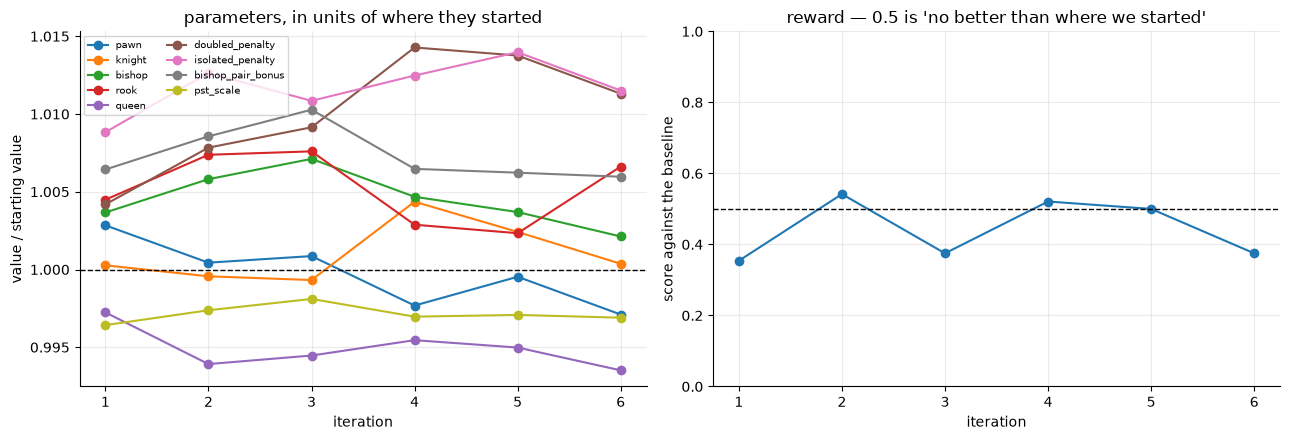

In [4]:
names = EvalParams.names()
start = DEFAULT_PARAMS.to_vector()
trajectory = np.array([step.params.to_vector() for step in history]) / start

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5))
for index, name in enumerate(names):
    left.plot(range(1, len(history) + 1), trajectory[:, index], marker="o", label=name)
left.axhline(1.0, color="black", lw=1, ls="--")
left.set_xlabel("iteration"); left.set_ylabel("value / starting value")
left.set_title("parameters, in units of where they started")
left.legend(fontsize=7, ncol=2)

right.plot(range(1, len(history) + 1), [s.mean_reward for s in history], marker="o")
right.axhline(0.5, color="black", lw=1, ls="--")
right.set_ylim(0, 1); right.set_xlabel("iteration")
right.set_ylabel("score against the baseline")
right.set_title("reward — 0.5 is 'no better than where we started'")
plt.tight_layout(); plt.show()

## Reading this honestly

Two things to keep in view before believing any line on that chart.

**The noise floor.** With 4 games per candidate, a score is one of nine values
between 0 and 1. The antithetic pair cancels shared luck but not this
granularity — a difference of one drawn game moves the reward by 0.125, which
is larger than most real effects here. Movement in the left chart at this
budget is mostly random walk.

**The reward is not Elo.** It is the score against a *fixed* baseline, so it
saturates: once a candidate is clearly better the number stops rising even if
it keeps improving. That is fine for a gradient and misleading as a progress
bar.

The run above is a demonstration of the machinery. The experiment it is a
sketch of would use `games=32, population=8, iterations=40` — about 20,000
games, a few hours across ten cores — and would still be measuring effects
close to its own error bars.

In [5]:
budget = lambda c: c.iterations * c.population * 2 * c.games
demo = config
serious = TuningConfig(iterations=40, population=8, games=32)
print(f"this notebook: {budget(demo):>6,} games")
print(f"a real run:    {budget(serious):>6,} games")
print(f"\nstandard error of a {serious.games}-game match: ~{0.5/np.sqrt(serious.games):.1%}")

this notebook:    144 games
a real run:    20,480 games

standard error of a 32-game match: ~8.8%
